1. 针对拼接H&E图像进行拆分，如 `Normal S47-50_1_1.tif` 要变成 `S47.tif` 和 `S50.tif`，拆分后的结果保存到 `data/interim/PGD_dataset/HE/DeYunKangRui`  

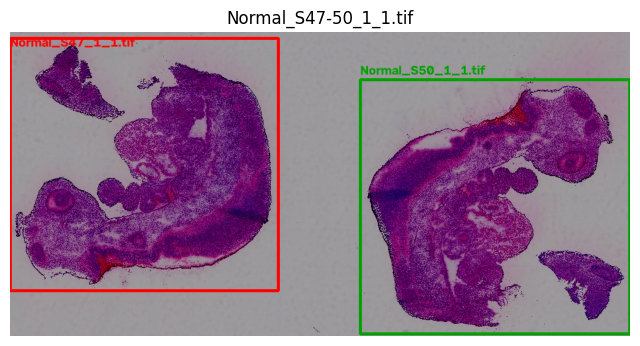

Normal_S47-50_1_1.tif -> Normal_S47_1_1.tif  shape=(14144, 15028, 3)
Normal_S47-50_1_1.tif -> Normal_S50_1_1.tif  shape=(14246, 15087, 3)


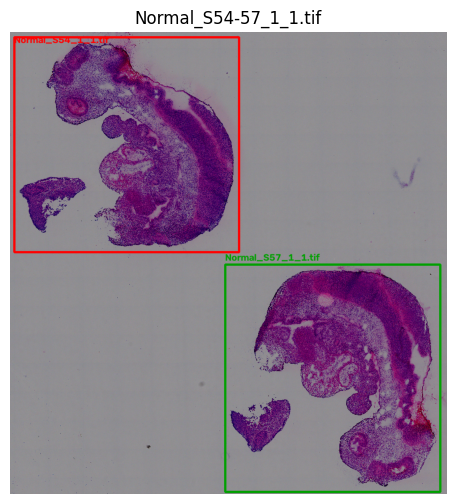

Normal_S54-57_1_1.tif -> Normal_S54_1_1.tif  shape=(14976, 15648, 3)
Normal_S54-57_1_1.tif -> Normal_S57_1_1.tif  shape=(15840, 14976, 3)


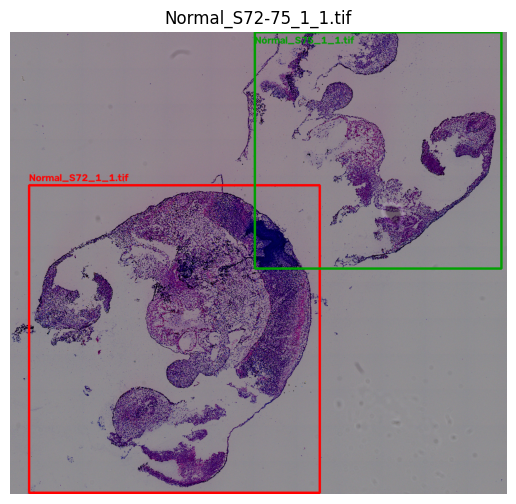

Normal_S72-75_1_1.tif -> Normal_S72_1_1.tif  shape=(17172, 16227, 3)
Normal_S72-75_1_1.tif -> Normal_S75_1_1.tif  shape=(13203, 13770, 3)


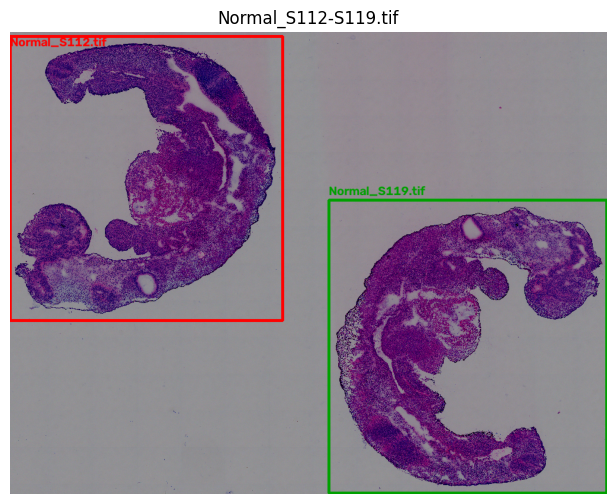

Normal_S112-S119.tif -> Normal_S112.tif  shape=(15360, 14720, 3)
Normal_S112-S119.tif -> Normal_S119.tif  shape=(15840, 14986, 3)


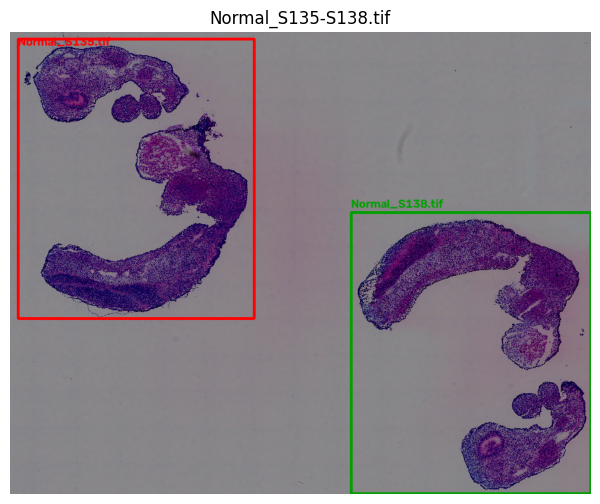

Normal_S135-S138.tif -> Normal_S135.tif  shape=(15314, 12927, 3)
Normal_S135-S138.tif -> Normal_S138.tif  shape=(15380, 13094, 3)


In [12]:
import os
import re
import cv2
import numpy as np
import tifffile
import matplotlib.pyplot as plt

DeYunKangRui_input_dir = "/mnt/zzf_nas/A_xff/Spaceland-omics/data/raw/PGD_dataset/HE/DeYunKangRui"
DeYunKangRui_output_dir = "/mnt/zzf_nas/A_xff/Spaceland-omics/data/interim/PGD_dataset/HE/DeYunKangRui"
os.makedirs(DeYunKangRui_output_dir, exist_ok=True)

Merged_image_list = [
    "Normal_S47-50_1_1.tif",
    "Normal_S54-57_1_1.tif",
    "Normal_S72-75_1_1.tif",
    "Normal_S112-S119.tif",
    "Normal_S135-S138.tif",
]


def parse_split_names(fname):
    """Normal_S47-50_1_1.tif -> (Normal_S47_1_1.tif, Normal_S50_1_1.tif)"""
    m = re.match(r"(Normal_)S(\d+)-S?(\d+)(.*)\.tif$", fname)
    if not m:
        raise ValueError(f"无法解析文件名: {fname}")
    prefix, a, b, rest = m.groups()
    return f"{prefix}S{a}{rest}.tif", f"{prefix}S{b}{rest}.tif"


def detect_two_tissue_boxes(small_rgb, pad_px=12):
    """降采样图上用 OpenCV 找到两块组织的紧包围盒，按从左到右排序。
    开运算去灰尘、不再膨胀；以两块最大连通域为种子，只合并足够大的邻近碎块。
    """
    gray = cv2.cvtColor(small_rgb, cv2.COLOR_RGB2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9)))

    h, w = mask.shape
    n_cc, cc, stats, cents = cv2.connectedComponentsWithStats(mask, connectivity=8)
    min_area = max(80, int(0.0004 * h * w))
    comps = [i for i in range(1, n_cc) if stats[i, cv2.CC_STAT_AREA] >= min_area]
    comps = sorted(comps, key=lambda i: stats[i, cv2.CC_STAT_AREA], reverse=True)
    if len(comps) < 2:
        raise RuntimeError("未检测到两块足够大的组织")

    seeds = comps[:2]
    seed_xy = cents[seeds][:, :2]
    seed_area = stats[seeds, cv2.CC_STAT_AREA].astype(np.float64)
    groups = {0: [seeds[0]], 1: [seeds[1]]}
    for i in comps[2:]:
        dist = np.linalg.norm(seed_xy - cents[i][:2], axis=1)
        k = int(np.argmin(dist))
        if stats[i, cv2.CC_STAT_AREA] >= 0.05 * seed_area[k]:
            groups[k].append(i)

    boxes = []
    for k in range(2):
        cluster_mask = np.isin(cc, groups[k]).astype(np.uint8) * 255
        ys, xs = np.where(cluster_mask > 0)
        x0, x1 = int(xs.min()) - pad_px, int(xs.max()) + 1 + pad_px
        y0, y1 = int(ys.min()) - pad_px, int(ys.max()) + 1 + pad_px
        x0, y0 = max(0, x0), max(0, y0)
        x1, y1 = min(w, x1), min(h, y1)
        boxes.append((float(xs.mean()), float(ys.mean()), x0, y0, x1, y1, cluster_mask))
    boxes.sort(key=lambda t: (t[0], t[1]))
    return boxes


def split_merged_tif(fname, show_preview=True):
    src = os.path.join(DeYunKangRui_input_dir, fname)
    name_a, name_b = parse_split_names(fname)
    img = tifffile.memmap(src)  # 超大 TIFF 不要 cv2.imread + 全图 cvtColor
    H, W = img.shape[:2]
    step = max(1, max(H, W) // 1000)
    small = np.ascontiguousarray(img[::step, ::step, :3])
    boxes = detect_two_tissue_boxes(small)
    out_names = [name_a, name_b]

    if show_preview:
        vis = small.copy()
        for i, (_, _, x0, y0, x1, y1, _) in enumerate(boxes):
            color = (255, 0, 0) if i == 0 else (0, 160, 0)
            cv2.rectangle(vis, (x0, y0), (x1 - 1, y1 - 1), color, 3)
            cv2.putText(vis, out_names[i], (x0, max(24, y0 - 8)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2, cv2.LINE_AA)
        plt.figure(figsize=(8, 6))
        plt.imshow(vis)
        plt.axis("off")
        plt.title(fname)
        plt.show()

    bg = np.median(np.concatenate([
        small[:16, :16].reshape(-1, 3),
        small[:16, -16:].reshape(-1, 3),
        small[-16:, :16].reshape(-1, 3),
        small[-16:, -16:].reshape(-1, 3),
    ]), axis=0).astype(np.uint8)

    for i, (_, _, x0, y0, x1, y1, _) in enumerate(boxes):
        X0, Y0 = x0 * step, y0 * step
        X1, Y1 = min(W, x1 * step), min(H, y1 * step)
        crop = np.array(img[Y0:Y1, X0:X1, :3], copy=True)
        other_small = boxes[1 - i][6][y0:y1, x0:x1]
        if other_small.any():
            other_full = cv2.resize(
                other_small, (crop.shape[1], crop.shape[0]),
                interpolation=cv2.INTER_NEAREST,
            )
            crop[other_full > 0] = bg
        out_path = os.path.join(DeYunKangRui_output_dir, out_names[i])
        tifffile.imwrite(out_path, crop, photometric="rgb")
        print(f"{fname} -> {out_names[i]}  shape={crop.shape}")


for fname in Merged_image_list:
    split_merged_tif(fname)

可视化

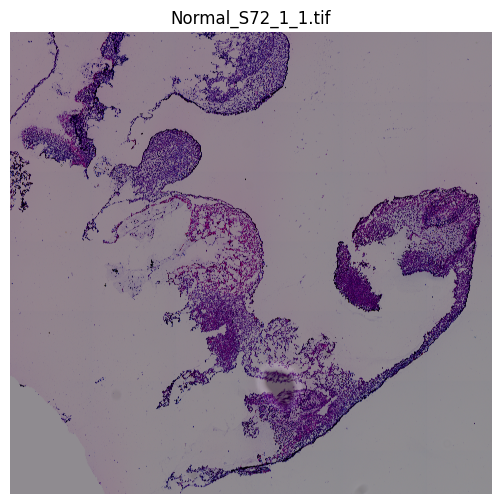

In [13]:
from matplotlib import pyplot as plt
import tifffile

img_path = "/mnt/zzf_nas/A_xff/Spaceland-omics/data/interim/PGD_dataset/HE/DeYunKangRui/Normal_S75_1_1.tif"
img = tifffile.imread(img_path)
plt.figure(figsize=(8, 6))
if img.ndim == 3 and img.shape[2] >= 3:
    plt.imshow(img[..., :3])
else:
    plt.imshow(img, cmap='gray')
plt.axis("off")
plt.title("Normal_S72_1_1.tif")
plt.show()